# Detecção de resíduos com YOLOv8

Alunos: Cauã Melo, Gisele de Oliveira, João Pedro de Oliveira, João Vittor Oliveira Costa e Matheus Pontieri

Este notebook registra o desenvolvimento de um detector de resíduos para imagens da natureza, usando o dataset TACO no formato do YOLOv8.

O objetivo é localizar os resíduos na foto e marcar cada detecção com uma caixa.

O notebook segue esta ordem:

1. preparar o ambiente local;
2. validar GPU e dependências;
3. conferir o dataset;
4. treinar um modelo base com `yolov8n`;
5. olhar métricas e exemplos de detecção;
6. separar o peso final para a demo em Streamlit.


## 1. Ambiente local

O projeto foi configurado para rodar localmente no Windows, usando a GPU NVIDIA RTX 4060 Ti 8GB.

Os comandos abaixo montam o ambiente a partir da pasta do projeto:

```powershell
python -m venv .venv
.\.venv\Scripts\python.exe -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
.\.venv\Scripts\python.exe -m pip install ultralytics notebook ipykernel matplotlib pandas opencv-python pyyaml
.\.venv\Scripts\python.exe -m notebook TACO.ipynb
```

Se o Windows estiver usando o Python Launcher, `py -3.12` pode substituir `python` no primeiro comando.

O fluxo principal fica local e não depende de Colab, Roboflow ou chave de API.


In [21]:
from pathlib import Path

import torch
import ultralytics
from ultralytics import YOLO

PROJECT_DIR = Path(".").resolve()
DATASET_DIR = PROJECT_DIR / "dataset"
DATA_YAML = DATASET_DIR / "data.yaml"
OUTPUT_DIR = PROJECT_DIR / "output"
RUNS_DIR = PROJECT_DIR / "runs"

BASE_RUN_NAME = "taco_yolov8n_base"
ADJUSTED_RUN_NAME = "taco_yolov8n_epochs50"

BASE_RUN_DIR = RUNS_DIR / BASE_RUN_NAME
ADJUSTED_RUN_DIR = RUNS_DIR / ADJUSTED_RUN_NAME
BASE_WEIGHTS = BASE_RUN_DIR / "weights" / "best.pt"
ADJUSTED_WEIGHTS = ADJUSTED_RUN_DIR / "weights" / "best.pt"
FINAL_WEIGHTS = OUTPUT_DIR / "best.pt"

DEVICE = 0 if torch.cuda.is_available() else "cpu"

print(f"Projeto: {PROJECT_DIR}")
print(f"Dataset: {DATASET_DIR}")
print(f"PyTorch: {torch.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU não detectada. O treino em CPU deve ficar muito mais lento.")


Projeto: C:\Users\tanz\Documents\unitins\IA\taco
Dataset: C:\Users\tanz\Documents\unitins\IA\taco\dataset
PyTorch: 2.11.0+cu128
Ultralytics: 8.4.50
CUDA disponível: True
GPU: NVIDIA GeForce RTX 4060 Ti


## 2. Dataset local

O dataset TACO fica em `dataset/`, já convertido para o formato que o YOLOv8 espera.

A estrutura usada foi esta:

```text
dataset/
  data.yaml
  train/images/
  train/labels/
  valid/images/
  valid/labels/
  test/images/
  test/labels/
```

Neste trabalho, o modelo foi treinado para localizar resíduos. Quando o `data.yaml` tem uma única classe, como `trash`, o modelo aprende a marcar lixo na imagem, mas não separa tipos como plástico, metal ou papel.


In [22]:
import yaml

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}


def resolve_dataset_path(value):
    path = Path(str(value))
    return path if path.is_absolute() else DATA_YAML.parent / path


def labels_dir_for(images_path):
    parts = list(images_path.parts)
    if "images" in parts:
        parts[parts.index("images")] = "labels"
        return Path(*parts)
    return images_path.parent / "labels"


def count_files(path, extensions):
    if not path.exists():
        return 0
    return sum(1 for item in path.rglob("*") if item.is_file() and item.suffix.lower() in extensions)


if not DATA_YAML.exists():
    raise FileNotFoundError("Coloque o dataset YOLOv8 em dataset/ com o arquivo dataset/data.yaml.")

with DATA_YAML.open("r", encoding="utf-8") as file:
    config_dataset = yaml.safe_load(file) or {}

for key in ["train", "val", "names"]:
    if key not in config_dataset:
        raise KeyError(f"Campo obrigatório ausente no data.yaml: {key}")

# Alguns exports do Roboflow usam ../train/images, mas neste projeto os splits ficam dentro de dataset/.
expected_splits = {"train": "train", "val": "valid", "test": "test"}
changed = False
for split_key, folder_name in expected_splits.items():
    if split_key not in config_dataset:
        continue
    configured_path = resolve_dataset_path(config_dataset[split_key])
    local_path = DATASET_DIR / folder_name / "images"
    if not configured_path.exists() and local_path.exists():
        config_dataset[split_key] = f"{folder_name}/images"
        changed = True

if changed:
    with DATA_YAML.open("w", encoding="utf-8") as file:
        yaml.safe_dump(config_dataset, file, sort_keys=False, allow_unicode=True)
    print("Caminhos do data.yaml ajustados para a estrutura local em dataset/.")

names = config_dataset["names"]
class_names = list(names.values()) if isinstance(names, dict) else list(names)
print(f"Arquivo de configuração: {DATA_YAML}")
print(f"Classes ({len(class_names)}): {class_names}")

for split_key in ["train", "val", "test"]:
    if split_key not in config_dataset:
        print(f"{split_key}: não informado")
        continue

    images_path = resolve_dataset_path(config_dataset[split_key])
    labels_path = labels_dir_for(images_path)
    image_count = count_files(images_path, IMAGE_EXTENSIONS)
    label_count = count_files(labels_path, {".txt"})

    if not images_path.exists():
        raise FileNotFoundError(f"Split {split_key} não encontrado: {images_path}")
    if image_count == 0:
        raise ValueError(f"Split {split_key} não possui imagens em {images_path}")

    print(f"{split_key}: {image_count} imagens, {label_count} labels")


Caminhos do data.yaml ajustados para a estrutura local em dataset/.
Arquivo de configuração: C:\Users\tanz\Documents\unitins\IA\taco\dataset\data.yaml
Classes (1): ['trash']
train: 1049 imagens, 1049 labels
val: 299 imagens, 299 labels
test: 151 imagens, 151 labels


## 3. Escolha do YOLOv8

YOLOv8 foi usado porque já trabalha diretamente com detecção de objetos. Ele recebe a imagem e devolve caixas, classes e confianças para o que encontrou.

A escolha fez sentido para este trabalho porque:

- resolve diretamente o problema de localizar resíduos na imagem;
- já vem com pesos pré-treinados, o que reduz o custo de treino;
- possui comandos simples para treino, validação e inferência;
- a versão `yolov8n` é leve o suficiente para testar o fluxo em uma GPU de 8GB.

A primeira etapa foi deixar uma versão base funcionando. Depois disso, as melhorias puderam ser comparadas sem mudar vários fatores ao mesmo tempo.


## 4. Treinamento base

O treino base usa uma configuração segura para a RTX 4060 Ti 8GB: `yolov8n`, imagem 640 e batch 8.

Se a GPU ficar sem memória, o primeiro ajuste é reduzir o `batch` para 4. Para testar rapidamente se tudo está funcionando, também dá para diminuir a quantidade de épocas.


In [23]:
model = YOLO("yolov8n.pt")

train_results = model.train(
    data=str(DATA_YAML),
    epochs=25,
    imgsz=640,
    batch=8,
    device=DEVICE,
    plots=True,
    project=str(RUNS_DIR),
    name=BASE_RUN_NAME,
    exist_ok=True,
)

BASE_RUN_DIR = Path(train_results.save_dir)
BASE_WEIGHTS = BASE_RUN_DIR / "weights" / "best.pt"

print(f"Resultados salvos em: {BASE_RUN_DIR}")
print(f"Melhor peso: {BASE_WEIGHTS}")


New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\tanz\Documents\unitins\IA\taco\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.93

## 5. Avaliação do treino

Depois do treino, os arquivos salvos pelo YOLOv8 em `runs/taco_yolov8n_base/` são usados para conferir o resultado.

Para explicar o resultado em sala, os pontos principais são:

- `Precision`: das detecções feitas, quantas estavam corretas;
- `Recall`: dos objetos reais, quantos o modelo encontrou;
- `mAP50` e `mAP50-95`: qualidade geral das caixas de detecção;
- exemplos visuais para mostrar acertos e erros.


Ultralytics 8.4.50  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.20.1 ms, read: 616.9267.8 MB/s, size: 1444.8 KB)
val: Scanning C:\Users\tanz\Documents\unitins\IA\taco\dataset\test\labels... 151 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 151/151 2.0Kit/s 0.1s
val: New cache created: C:\Users\tanz\Documents\unitins\IA\taco\dataset\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 14.8it/s 1.3s0.1s
                   all        151        570      0.591      0.321      0.351      0.244
Speed: 0.9ms preprocess, 1.7ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to C:\Users\tanz\Documents\unitins\IA\taco\output\avaliacao_base


,modelo,epochs,precision,recall,mAP50,mAP50-95
0,base_yolov8n_25ep,25,0.590904,0.321053,0.351312,0.244429


### Resumo do treino

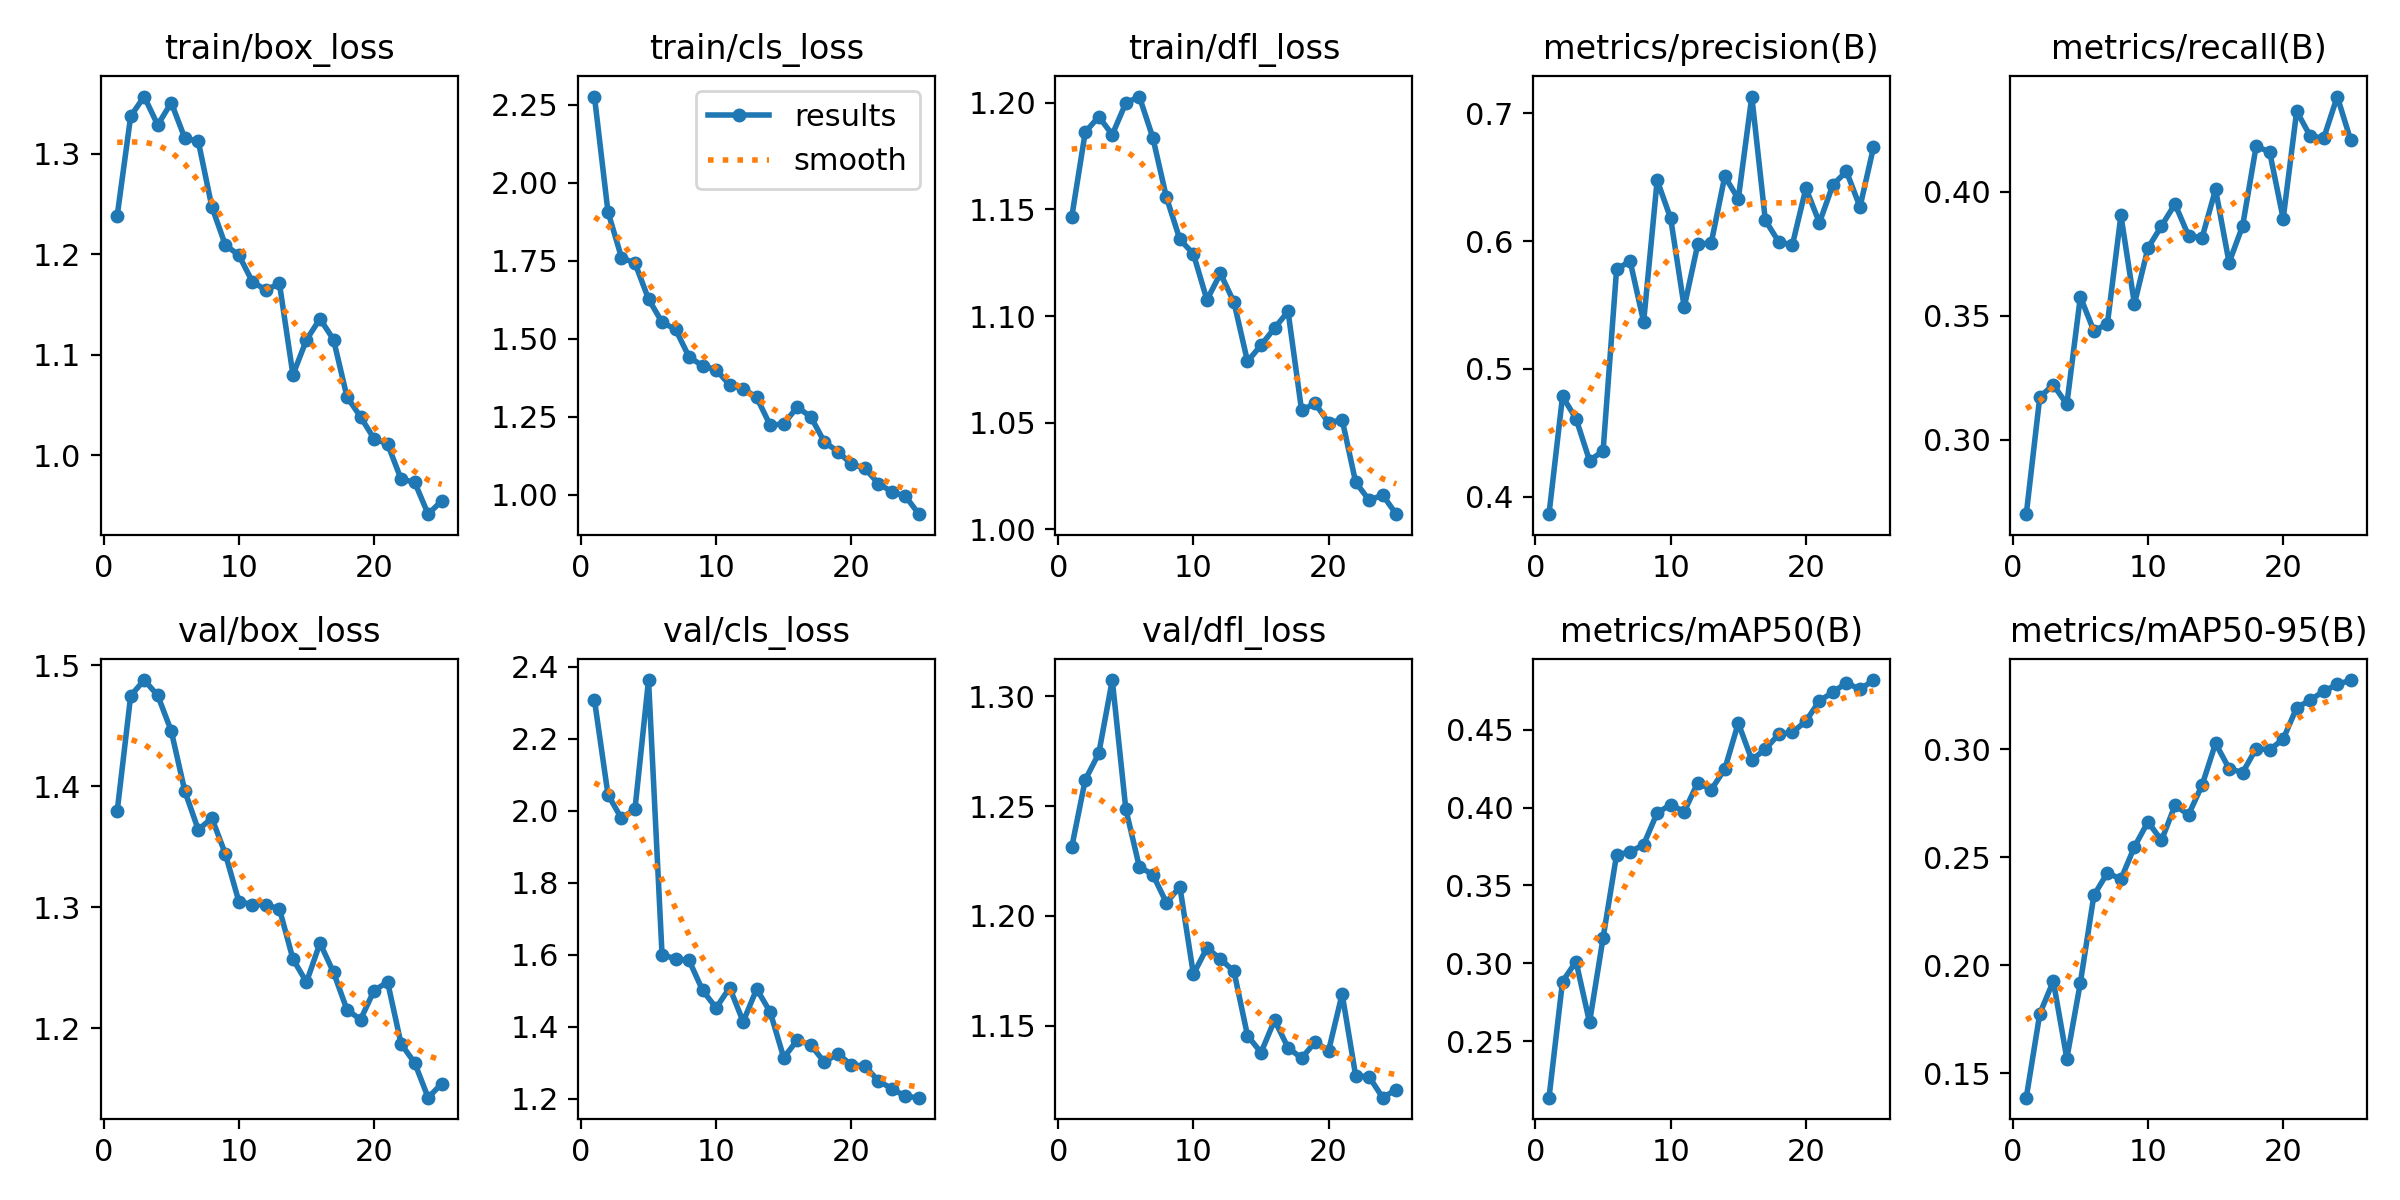

### Matriz de confusão no teste

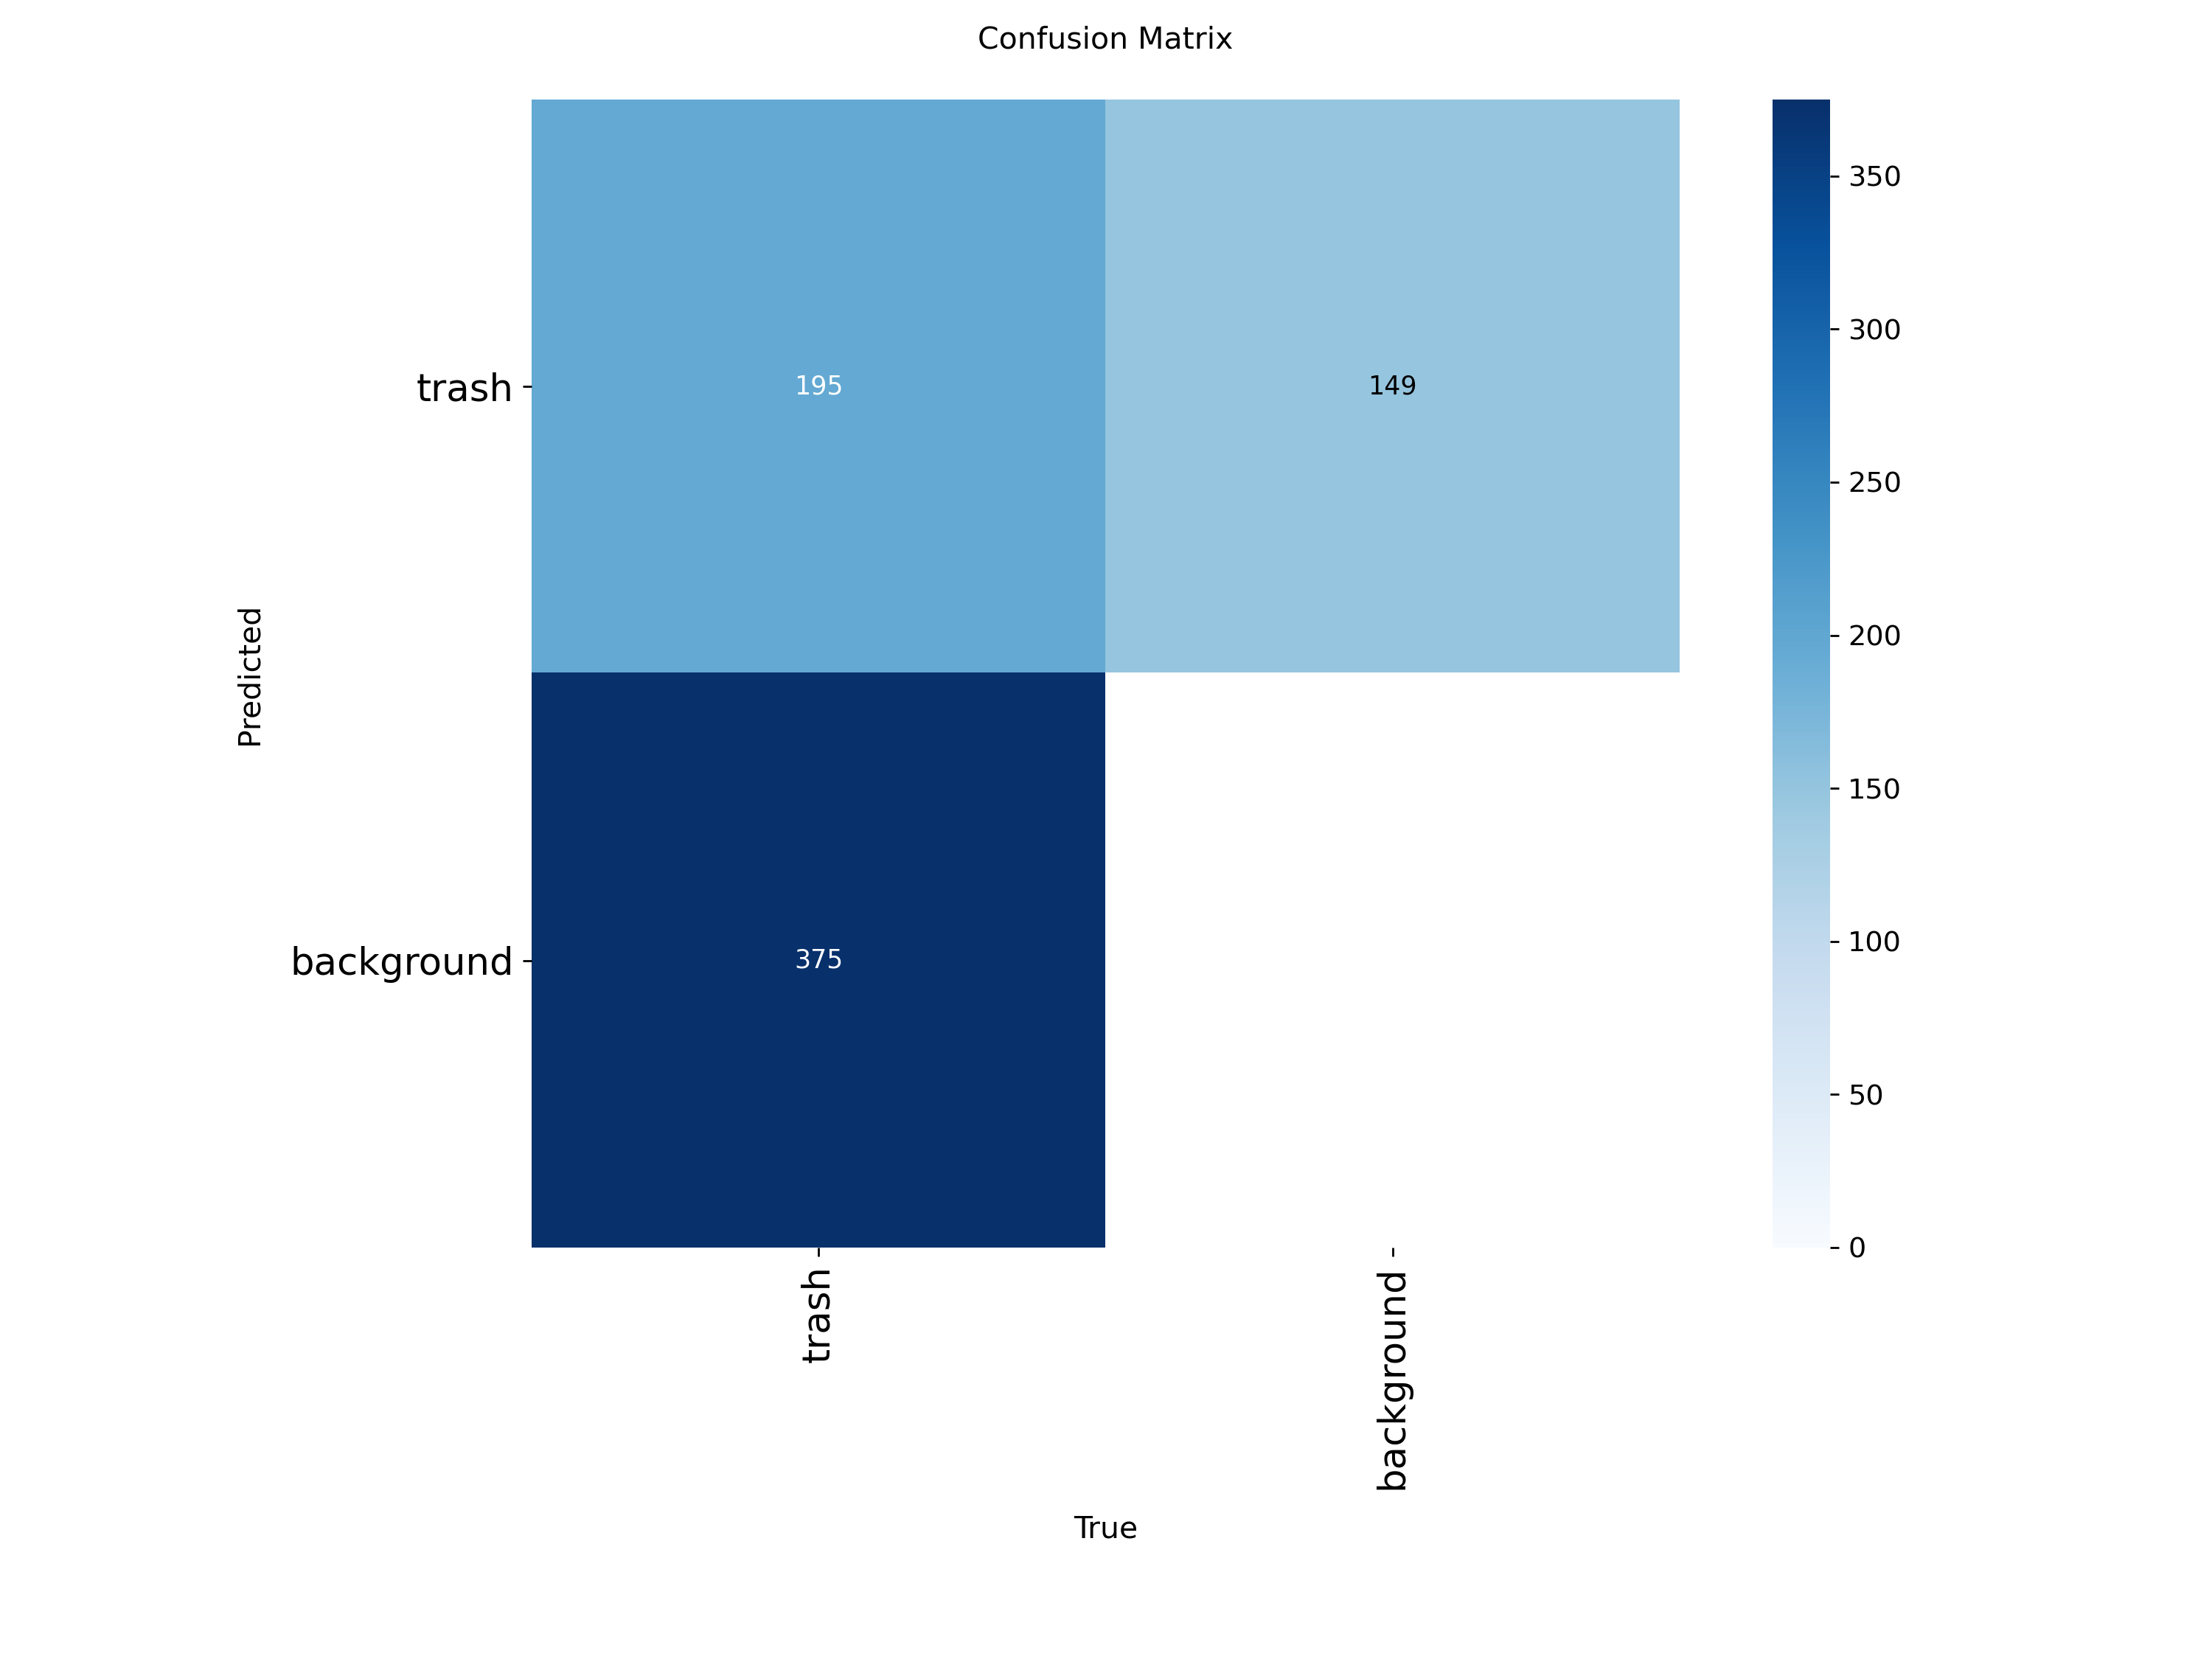

### Curva Precision-Recall no teste

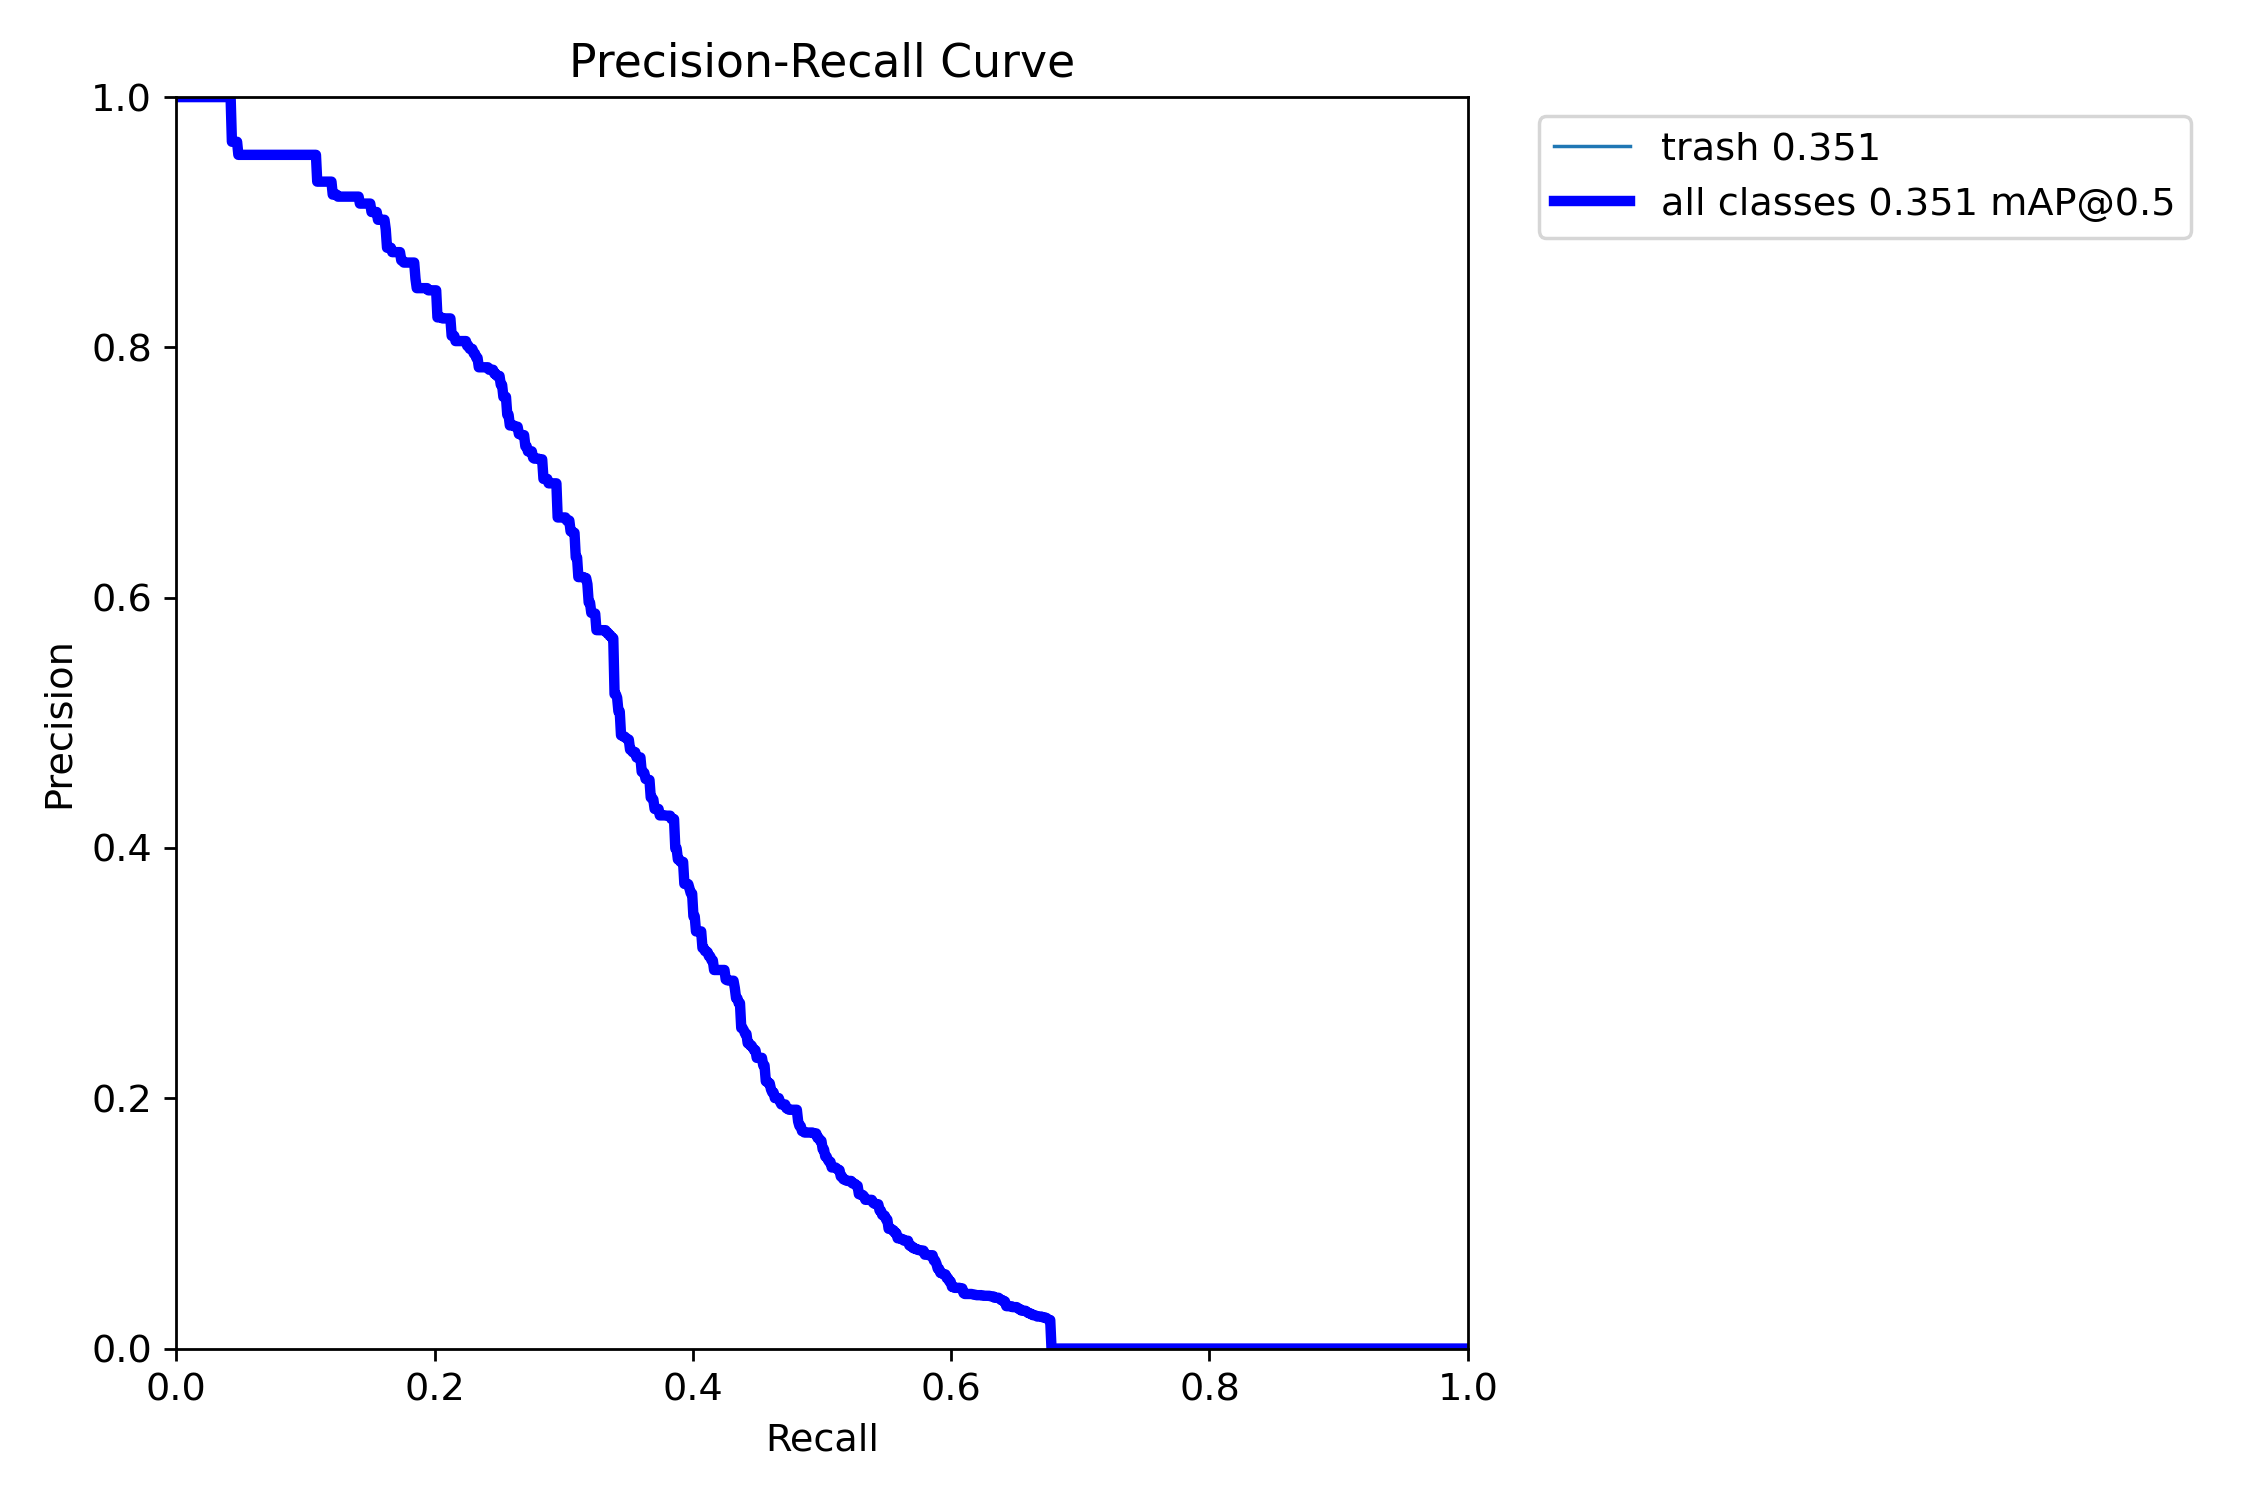

In [24]:
import pandas as pd
from IPython.display import Image, Markdown, display


def metrics_to_row(modelo, epochs, metrics):
    return {
        "modelo": modelo,
        "epochs": epochs,
        "precision": float(metrics.box.mp),
        "recall": float(metrics.box.mr),
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
    }


def show_graph(title, path, width=900):
    path = Path(path)
    if path.exists():
        display(Markdown(f"### {title}"))
        display(Image(filename=str(path), width=width))
    else:
        print(f"Gráfico não encontrado: {path}")


if not BASE_WEIGHTS.exists():
    print("Peso base ainda não encontrado. Rode o treinamento base primeiro.")
else:
    BASE_EVAL_DIR = OUTPUT_DIR / "avaliacao_base"
    model = YOLO(str(BASE_WEIGHTS))
    metrics_base_result = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=640,
        batch=8,
        device=DEVICE,
        plots=True,
        project=str(OUTPUT_DIR),
        name=BASE_EVAL_DIR.name,
        exist_ok=True,
    )

    base_metrics = metrics_to_row("base_yolov8n_25ep", 25, metrics_base_result)
    display(pd.DataFrame([base_metrics]))

    show_graph("Resumo do treino", BASE_RUN_DIR / "results.png", 1000)
    show_graph("Matriz de confusão no teste", BASE_EVAL_DIR / "confusion_matrix.png")
    show_graph("Curva Precision-Recall no teste", BASE_EVAL_DIR / "BoxPR_curve.png")


## 6. Inferência visual

Com o `best.pt` gerado no treino, uma imagem do conjunto de teste local é usada para inferência.

O resultado visual mostra onde o modelo marcou os resíduos e ajuda a comparar as métricas com exemplos reais.


In [25]:
import matplotlib.pyplot as plt

TEST_IMAGES_DIR = DATASET_DIR / "test" / "images"
WEIGHTS_FOR_INFERENCE = FINAL_WEIGHTS if FINAL_WEIGHTS.exists() else BASE_WEIGHTS

if not WEIGHTS_FOR_INFERENCE.exists():
    print("Nenhum peso encontrado. Rode o treinamento primeiro.")
elif not TEST_IMAGES_DIR.exists():
    print("Pasta dataset/test/images não encontrada.")
else:
    test_images = sorted(path for path in TEST_IMAGES_DIR.iterdir() if path.suffix.lower() in IMAGE_EXTENSIONS)

    if not test_images:
        print("Nenhuma imagem encontrada em dataset/test/images.")
    else:
        model = YOLO(str(WEIGHTS_FOR_INFERENCE))
        predictions = model.predict(source=str(test_images[0]), save=False, conf=0.25)
        result = predictions[0]

        plt.figure(figsize=(10, 8))
        plt.imshow(result.plot()[:, :, ::-1])
        plt.axis("off")
        plt.show()

        print(f"Peso usado: {WEIGHTS_FOR_INFERENCE}")
        print(f"Imagem testada: {test_images[0]}")
        print(f"Detecções encontradas: {len(result.boxes)}")

        for box in result.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = result.names.get(class_id, str(class_id))
            print(f"- {class_name}: {confidence:.2%}")



image 1/1 C:\Users\tanz\Documents\unitins\IA\taco\dataset\test\images\000001_JPG_jpg.rf.9d4dd9d178184309f312c6e4fe83cfcf.jpg: 640x480 5 trashs, 9.2ms
Speed: 2.8ms preprocess, 9.2ms inference, 3.6ms postprocess per image at shape (1, 3, 640, 480)


<Figure size 1000x800 with 1 Axes>

Peso usado: C:\Users\tanz\Documents\unitins\IA\taco\runs\taco_yolov8n_base\weights\best.pt
Imagem testada: C:\Users\tanz\Documents\unitins\IA\taco\dataset\test\images\000001_JPG_jpg.rf.9d4dd9d178184309f312c6e4fe83cfcf.jpg
Detecções encontradas: 5
- trash: 93.13%
- trash: 39.86%
- trash: 36.80%
- trash: 36.63%
- trash: 32.12%


## 7. Peso final para a aplicação

O peso base pode ser copiado para `output/best.pt` para testar a aplicação Streamlit. Depois da comparação com 50 épocas, a seção seguinte pode substituir esse arquivo pelo melhor peso.


In [26]:
import shutil

if BASE_WEIGHTS.exists():
    FINAL_WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(BASE_WEIGHTS, FINAL_WEIGHTS)
    print(f"Peso base copiado para: {FINAL_WEIGHTS}")
else:
    print("Peso base ainda não existe. Rode o treinamento base antes de copiar.")


Peso base copiado para: C:\Users\tanz\Documents\unitins\IA\taco\output\best.pt


## 8. Teste com mais épocas

Para testar uma melhoria sem prejudicar a comparação, apenas um fator foi alterado: o treino passou de 25 para 50 épocas.

Foram mantidos:

- modelo `yolov8n`;
- `imgsz=640`;
- `batch=8`;
- mesmo dataset local em `dataset/data.yaml`;
- avaliação no mesmo split `test`.

Esse ajuste foi escolhido porque, no treino base, as métricas ainda estavam melhorando na última época. Aumentar apenas `epochs` foi o jeito mais simples de testar se o modelo ainda podia aprender mais.


New https://pypi.org/project/ultralytics/8.4.51 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.50  Python-3.12.10 torch-2.11.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4060 Ti, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\tanz\Documents\unitins\IA\taco\dataset\data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.93

,modelo,epochs,precision,recall,mAP50,mAP50-95,delta_precision,delta_recall,delta_mAP50,delta_mAP50-95,selecionado
0,base_yolov8n_25ep,25,0.590904,0.321053,0.351312,0.244429,0.000000,0.000000,0.000000,0.000000,False
1,yolov8n_50ep,50,0.658672,0.352093,0.382694,0.252097,0.067768,0.031041,0.031383,0.007668,True


### Resumo do treino com 50 épocas

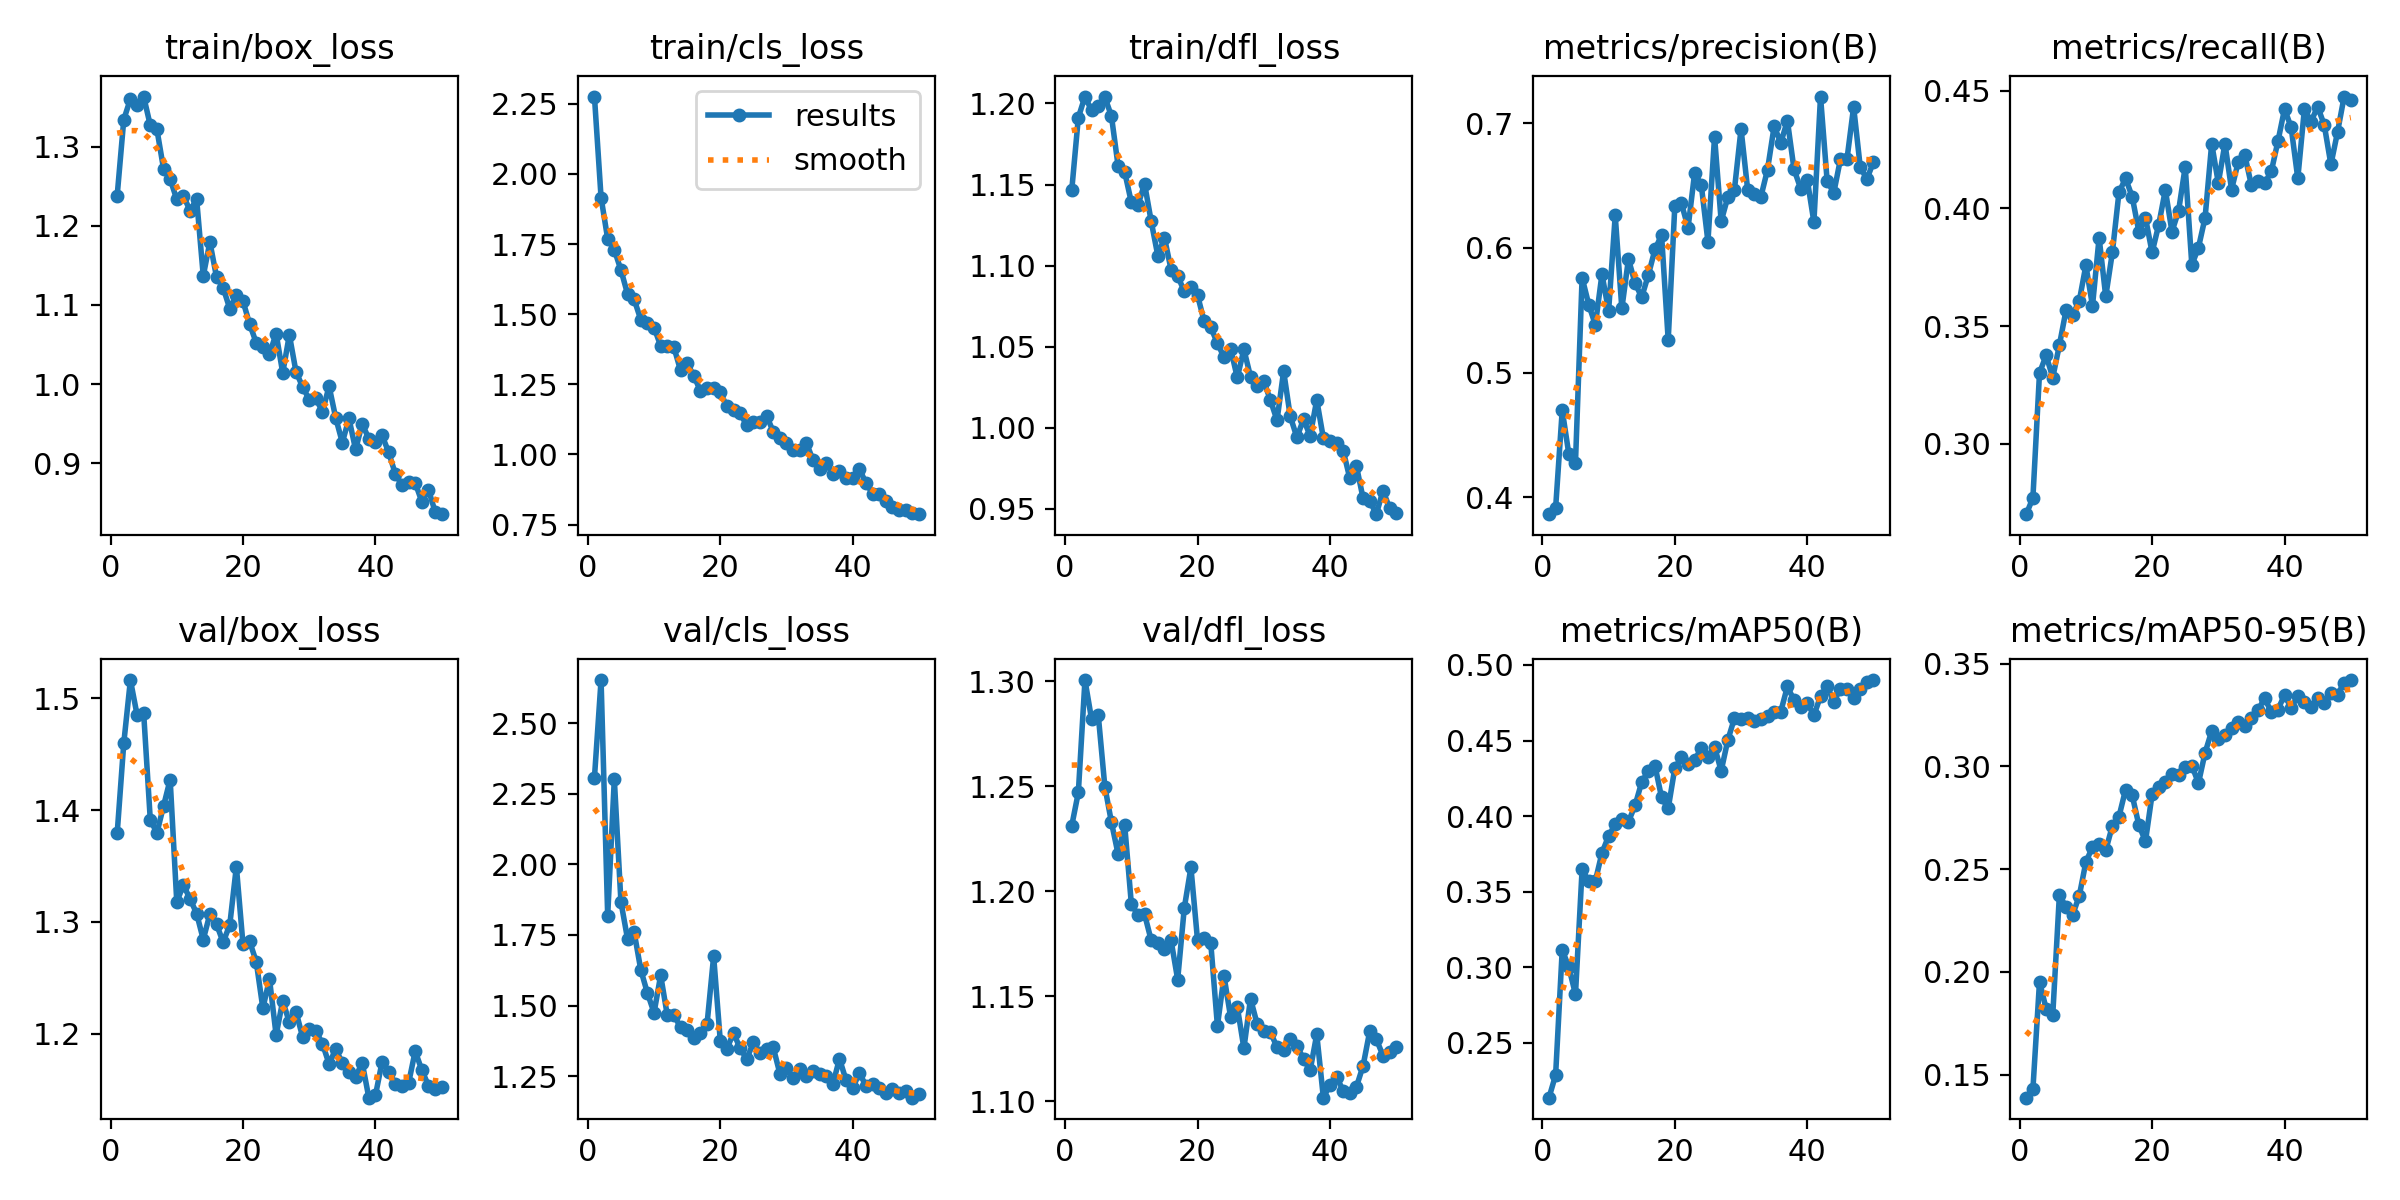

### Matriz de confusão no teste

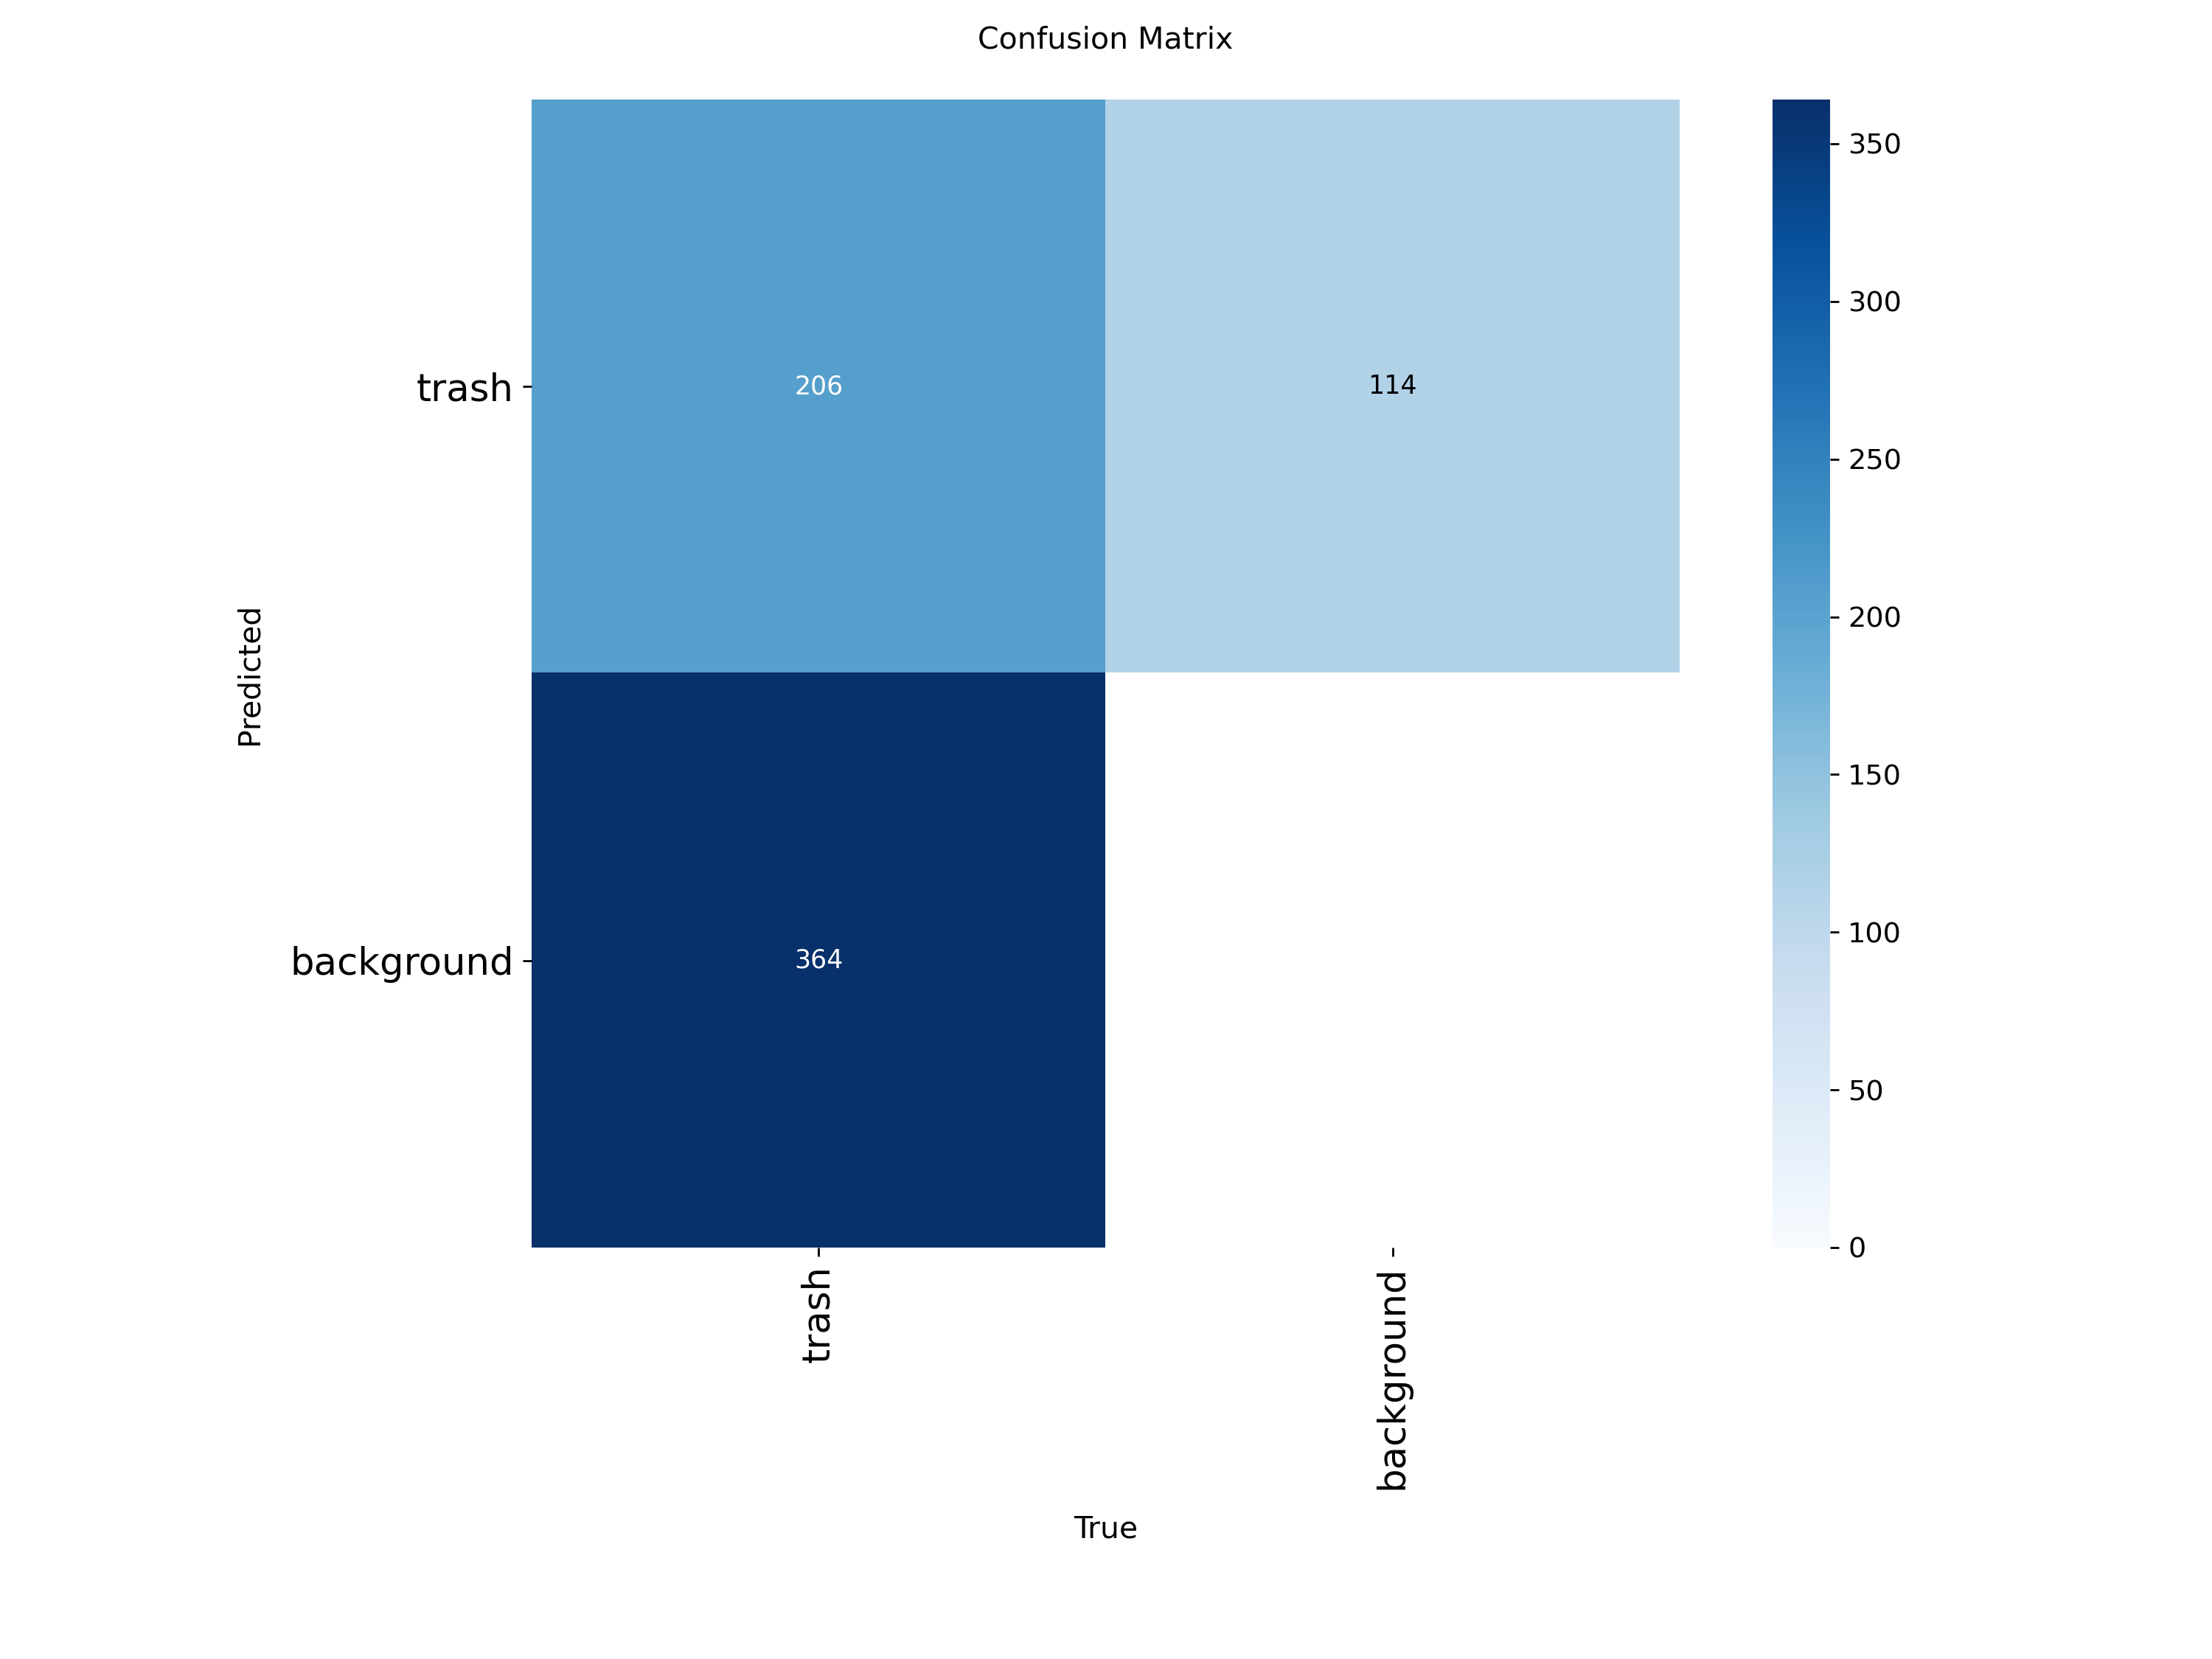

Modelo escolhido: yolov8n_50ep
Peso final da aplicação: C:\Users\tanz\Documents\unitins\IA\taco\output\best.pt


In [27]:
if "base_metrics" not in globals():
    raise RuntimeError("Rode a seção 5 antes, para gerar as métricas do modelo base.")

ADJUSTED_EPOCHS = 50

model = YOLO("yolov8n.pt")
train_adjusted = model.train(
    data=str(DATA_YAML),
    epochs=ADJUSTED_EPOCHS,
    imgsz=640,
    batch=8,
    device=DEVICE,
    plots=True,
    project=str(RUNS_DIR),
    name=ADJUSTED_RUN_NAME,
    exist_ok=True,
    seed=0,
    deterministic=True,
)

ADJUSTED_RUN_DIR = Path(train_adjusted.save_dir)
ADJUSTED_WEIGHTS = ADJUSTED_RUN_DIR / "weights" / "best.pt"
if not ADJUSTED_WEIGHTS.exists():
    raise FileNotFoundError(f"Peso ajustado não encontrado: {ADJUSTED_WEIGHTS}")

ADJUSTED_EVAL_DIR = OUTPUT_DIR / "avaliacao_epochs50"
model = YOLO(str(ADJUSTED_WEIGHTS))
metrics_adjusted_result = model.val(
    data=str(DATA_YAML),
    split="test",
    imgsz=640,
    batch=8,
    device=DEVICE,
    plots=True,
    project=str(OUTPUT_DIR),
    name=ADJUSTED_EVAL_DIR.name,
    exist_ok=True,
)

adjusted_metrics = metrics_to_row("yolov8n_50ep", ADJUSTED_EPOCHS, metrics_adjusted_result)
comparison = pd.DataFrame([base_metrics, adjusted_metrics])

for metric in ["precision", "recall", "mAP50", "mAP50-95"]:
    comparison[f"delta_{metric}"] = comparison[metric] - comparison.loc[0, metric]

adjusted_is_better = (
    adjusted_metrics["mAP50-95"] > base_metrics["mAP50-95"]
    or (
        adjusted_metrics["mAP50-95"] == base_metrics["mAP50-95"]
        and adjusted_metrics["mAP50"] > base_metrics["mAP50"]
    )
)

chosen_model = adjusted_metrics["modelo"] if adjusted_is_better else base_metrics["modelo"]
chosen_weights = ADJUSTED_WEIGHTS if adjusted_is_better else BASE_WEIGHTS
comparison["selecionado"] = comparison["modelo"] == chosen_model

FINAL_WEIGHTS.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(chosen_weights, FINAL_WEIGHTS)
comparison.to_csv(OUTPUT_DIR / "comparacao_treinos.csv", index=False)

display(comparison)
show_graph("Resumo do treino com 50 épocas", ADJUSTED_RUN_DIR / "results.png", 1000)
show_graph("Matriz de confusão no teste", ADJUSTED_EVAL_DIR / "confusion_matrix.png")

print(f"Modelo escolhido: {chosen_model}")
print(f"Peso final da aplicação: {FINAL_WEIGHTS}")


## 9. Aplicação de demonstração

A demo local ficou em `app.py`. Ela carrega o peso escolhido em `output/best.pt`, permite enviar uma imagem, roda a inferência com YOLOv8 e mostra a imagem com as caixas detectadas.

Para abrir a aplicação:

```powershell
.\.venv\Scripts\streamlit.exe run app.py
```

Na tela, basta enviar uma imagem e ajustar a confiança mínima para esconder detecções muito fracas. A tabela mostra a classe detectada e a confiança de cada caixa.


## 10. Conclusão
O primeiro modelo base com 25 épocas teve estes resultados no teste:

- Precision: 0,591;
- Recall: 0,321;
- mAP50: 0,351;
- mAP50-95: 0,244.

Depois o treino foi aumentado para 50 épocas mantendo `yolov8n`, `imgsz=640` e `batch=8`. O novo modelo teve:

- Precision: 0,659;
- Recall: 0,352;
- mAP50: 0,383;
- mAP50-95: 0,252.

A `Precision` subiu de 0,591 para 0,659, indicando menos detecções falsas. O `Recall` subiu de 0,321 para 0,352, mostrando que o modelo encontrou mais resíduos, mas ainda deixou muitos objetos passarem. O `mAP50` subiu de 0,351 para 0,383, o que indica melhora geral na detecção. O `mAP50-95` subiu pouco, de 0,244 para 0,252, sinalizando que a precisão das caixas ainda é limitada quando a avaliação exige localizações mais rigorosas.

A melhora ocorreu porque o segundo treino teve mais tempo para ajustar os pesos (mais épocas). Ainda assim, o ganho foi moderado. Para melhorar mais, seria necessário revisar as configurações, aumentar a variedade das imagens, ajustar aumentos de dados, testar limiares de confiança e, se a GPU permitir, comparar com um modelo um pouco maior. O resultado atual é adequado como protótipo, mas ainda não como solução pronta para uso real.
